In [1]:
# Importing setup file
from setup import *
import requests

# Link directory to save figures
out_path = "output/p2"
os.makedirs(out_path, exist_ok=True)

## Loading Data Set

In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text

chars, chars_to_idx, idx_to_chars, encoded_text = vocab(translation=False, dataset=text)

print(f'Text Length: {len(text)}')
print(f'No, of Characters: {len(chars)}')
print(f'Using device: {device}')

Text Length: 1115394
No, of Characters: 65
Using device: cuda


### Hyperparameters

In [3]:
epochs = 50
batch_size = 128
input_size = len(chars)
output_size = input_size
seed = "ROMEO:\n"

## Helper Functions

In [4]:
def measure_inference_time(model, val_loader, n_runs=10):
    model.eval()
    batch = next(iter(val_loader))[0][:32].to(device)

    with torch.no_grad():
        for _ in range(3):
            model(batch)

    t0 = time.time()

    with torch.no_grad():
        for _ in range(n_runs):
            model(batch)
    
    return (time.time() - t0) / n_runs

In [5]:
def train_model(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Initializing metric variables
    train_losses = []
    val_losses = []
    val_accs = []

    start_time = time.time()

    for epoch in range(epochs):
        #Training loop
        model.train()
        epoch_train_loss = 0.0

        for train_x, train_y in train_loader:
            X_train = train_x.to(device)
            Y_train = train_y.to(device)

            optimizer.zero_grad()
            train_output = model(X_train)
            train_loss = criterion(train_output.transpose(1, 2), Y_train)
            train_loss.backward()
            optimizer.step()
            epoch_train_loss += train_loss.item()
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Loop
        model.eval()
        epoch_val_loss, epoch_val_acc = 0.0, 0.0

        with torch.no_grad():
            for val_x, val_y in val_loader:
                X_val = val_x.to(device)
                Y_val = val_y.to(device)

                val_output = model(X_val)
                val_loss = criterion(val_output.transpose(1, 2), Y_val)
                epoch_val_loss += val_loss.item()

                _, predicted = torch.max(val_output, 2)
                val_acc = (predicted == Y_val).float().mean()
                epoch_val_acc += val_acc.item()

            avg_val_loss = epoch_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)

            avg_val_acc = epoch_val_acc / len(val_loader)
            val_accs.append(avg_val_acc)

        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}:\n Loss: {train_loss.item():.3f}, Validation Loss: {val_loss.item():.3f}, Validation Accuracy: {val_acc.item():.4f}')

    train_time = time.time() - start_time

    return {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_acc': val_accs,
    'final_train_loss': train_losses[-1],
    'final_val_loss': val_losses[-1],
    'final_val_acc': val_accs[-1],
    'train_time': train_time,
    }

## Main Functions

In [6]:
def part1():
    part1 = {}
    seq_len = [20, 30]

    for seq in seq_len:
        part1[seq] = {}

        print("\n")
        print("="*30)
        print(f'Sequence length: {seq}')
        print("="*30)

        for config in transformer_configs:
            nlayers = config['num_layers']
            nheads = config['nhead']
            
            model = charTransformer(input_size=input_size, hidden_size=hidden_size, output_size=output_size, 
                                    num_layers=nlayers, nhead=nheads).to(device)
            dataset = CharDataset(encoded_text, seq_len=seq)
            train_loader, val_loader = build_loaders(dataset, batch_size=batch_size)
            
            # Properly initializing dictionaries
            if nlayers not in part1[seq]:
                part1[seq][nlayers] = {}
            part1[seq][nlayers][nheads] = {}

            print("\n")
            print("="*50)
            print(f'Number of Layers: {nlayers} |   Number of heads: {nheads}')
            print("="*50)

            metrics = train_model(model=model, train_loader=train_loader, val_loader=val_loader)
            model_size = compute_model_size(model)
            inf_time = measure_inference_time(model, val_loader)

            sample_input = torch.randint(0, input_size, (1, seq)).to(device)
            flops, params = compute_flops(model, sample_input)

            part1[seq][nlayers][nheads] = {
                **metrics,
                'model_size_mb': model_size,
                'complexity': flops,
                'no_params': params,
                'inf_time': inf_time,
            }
        
            plot_loss(train_losses=part1[seq][nlayers][nheads]['train_losses'], val_losses=part1[seq][nlayers][nheads]['val_losses'],
                  title=f'Evaluation Curves for CharTransformer Trained on Shakespeare Dataset (Seq: {seq}, Layers: {nlayers}, Heads: {nheads})',
                  path=f'{out_path}/charTransformer_shakespeare_len{seq}_layers{nlayers}_head{nheads}_evalCurve')
    
    for metric_name, key, fmt in [
    ("Final Train Loss",    "final_train_loss", ".4f"),
    ("Final Val Loss",      "final_val_loss",   ".4f"),
    ("Val Accuracy",        "final_val_acc",    ".4f"),
    ("Train Time (s)",      "train_time",       ".2f"),
    ("Inference Time (ms)", "inf_time",           ".3f"),
    ("No. of Params",       "no_params",           ""),
    ("FLOPs",               "complexity",       ""),
    ("Model Size (MB)",     "model_size_mb",          ".4f"),
    ]:
        print("\n")
        print(f'{metric_name}')
        for seq in seq_len:
            for config in transformer_configs:
                nlayers = config['num_layers']
                nheads = config['nhead']
                
                value = part1[seq][nlayers][nheads][key]
                try:
                    print(f'Sequence Length: {seq}\t Value: {value:{fmt}}')
                except (ValueError, TypeError):
                    print(f'Sequence Length: {seq}\t Value: {value}')

In [ ]:
def part2():
    part2 = {}
    seq_len = 50

    for config in transformer_configs:
        nlayers = config['num_layers']
        nheads = config['nhead']
    
        model = charTransformer(input_size, hidden_size, output_size, num_layers=nlayers, nhead=nheads).to(device)
        dataset = CharDataset(encoded_text, seq_len=seq_len)
        train_loader, val_loader = build_loaders(dataset, batch_size=batch_size)

        # Properly initializing dictionaries
        if nlayers not in part2:
            part2[nlayers] = {}
        part2[nlayers][nheads] = {}

        print("\n")
        print("="*50)
        print(f'Sequence Length: {seq_len}  |   Number of Layers: {nlayers} |   Number of heads: {nheads}')
        print("="*50)

        metrics = train_model(model, train_loader=train_loader, val_loader=val_loader)
        model_size = compute_model_size(model)
        inf_time = measure_inference_time(model, val_loader=val_loader)

        sample_input = torch.randint(0, input_size, (1, seq_len)).to(device)
        flops, params = compute_flops(model, sample_input)

        part2[nlayers][nheads] = {
            **metrics,
            'model_size_mb': model_size,
            'complexity': flops,
            'no_params': params,
            'inf_time': inf_time,
        }

        plot_loss(train_losses=part2[nlayers][nheads]['train_losses'], val_losses=part2[nlayers][nheads]['val_losses'],
                  title=f'Evaluation Curves for CharTransformer Trained on Shakespeare Dataset (Seq: {seq_len}, Layers: {nlayers}, Heads: {nheads})',
                  path=f'{out_path}/charTransformer_shakespeare_len{seq_len}_layers{nlayers}_head{nheads}_evalCurve')
    
    for metric_name, key, fmt in [
    ("Final Train Loss",    "final_train_loss", ".4f"),
    ("Final Val Loss",      "final_val_loss",   ".4f"),
    ("Val Accuracy",        "final_val_acc",    ".4f"),
    ("Train Time (s)",      "train_time",       ".2f"),
    ("Inference Time (ms)", "inf_time",           ".3f"),
    ("No. of Params",       "no_params",           ""),
    ("FLOPs",               "complexity",       ""),
    ("Model Size (MB)",     "model_size_mb",          ".4f"),
    ]:
        print("\n")
        print(f'{metric_name}')
        for config in transformer_configs:
            nlayers = config['num_layers']
            nheads = config['nhead']
            
            value = part2[nlayers][nheads][key]
            try:
                print(f'Sequence Length: {seq_len}\t Value: {value:{fmt}}')
            except (ValueError, TypeError):
                print(f'Sequence Length: {seq_len}\t Value: {value}')

Part 1: Seq lengths 20 and 30    |   6 Transformer Configurations


Sequence length: 20


Number of Layers: 1 |   Number of heads: 2
Epoch 10:
 Loss: 0.109, Validation Loss: 0.078, Validation Accuracy: 0.9783
Epoch 20:
 Loss: 0.075, Validation Loss: 0.073, Validation Accuracy: 0.9783
Epoch 30:
 Loss: 0.099, Validation Loss: 0.071, Validation Accuracy: 0.9783
Epoch 40:
 Loss: 0.057, Validation Loss: 0.071, Validation Accuracy: 0.9778
Epoch 50:
 Loss: 0.075, Validation Loss: 0.069, Validation Accuracy: 0.9783


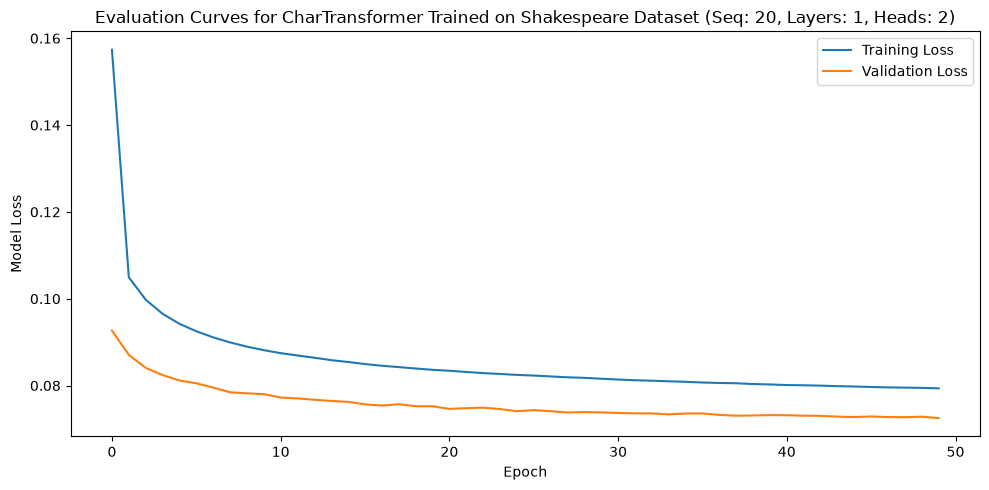



Number of Layers: 1 |   Number of heads: 4
Epoch 10:
 Loss: 0.099, Validation Loss: 0.076, Validation Accuracy: 0.9763
Epoch 20:
 Loss: 0.064, Validation Loss: 0.072, Validation Accuracy: 0.9793
Epoch 30:
 Loss: 0.089, Validation Loss: 0.071, Validation Accuracy: 0.9798
Epoch 40:
 Loss: 0.065, Validation Loss: 0.068, Validation Accuracy: 0.9788
Epoch 50:
 Loss: 0.033, Validation Loss: 0.066, Validation Accuracy: 0.9808


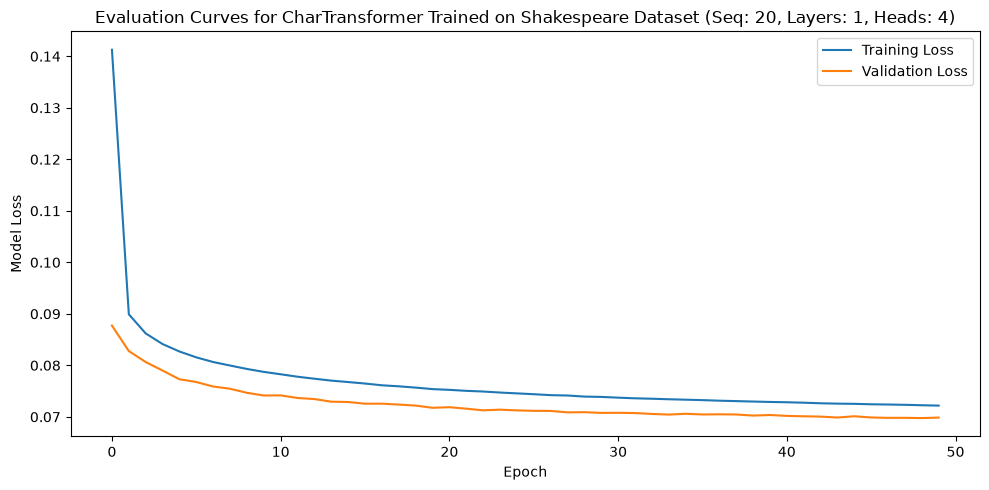



Number of Layers: 2 |   Number of heads: 2
Epoch 10:
 Loss: 0.094, Validation Loss: 0.073, Validation Accuracy: 0.9798
Epoch 20:
 Loss: 0.033, Validation Loss: 0.065, Validation Accuracy: 0.9813
Epoch 30:
 Loss: 0.084, Validation Loss: 0.067, Validation Accuracy: 0.9828
Epoch 40:
 Loss: 0.070, Validation Loss: 0.066, Validation Accuracy: 0.9808
Epoch 50:
 Loss: 0.070, Validation Loss: 0.064, Validation Accuracy: 0.9838


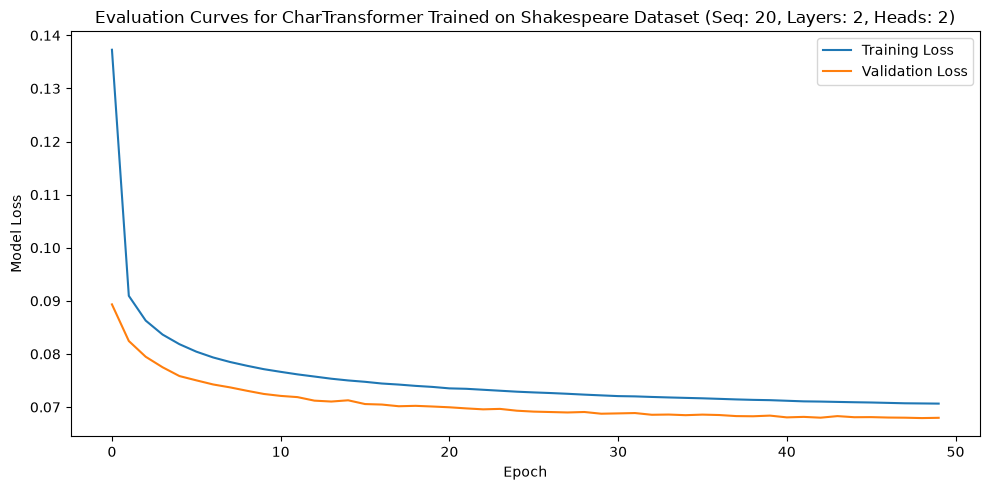



Number of Layers: 2 |   Number of heads: 4
Epoch 10:
 Loss: 0.116, Validation Loss: 0.069, Validation Accuracy: 0.9788
Epoch 20:
 Loss: 0.062, Validation Loss: 0.067, Validation Accuracy: 0.9803
Epoch 30:
 Loss: 0.056, Validation Loss: 0.066, Validation Accuracy: 0.9803
Epoch 40:
 Loss: 0.033, Validation Loss: 0.063, Validation Accuracy: 0.9818
Epoch 50:
 Loss: 0.088, Validation Loss: 0.062, Validation Accuracy: 0.9838


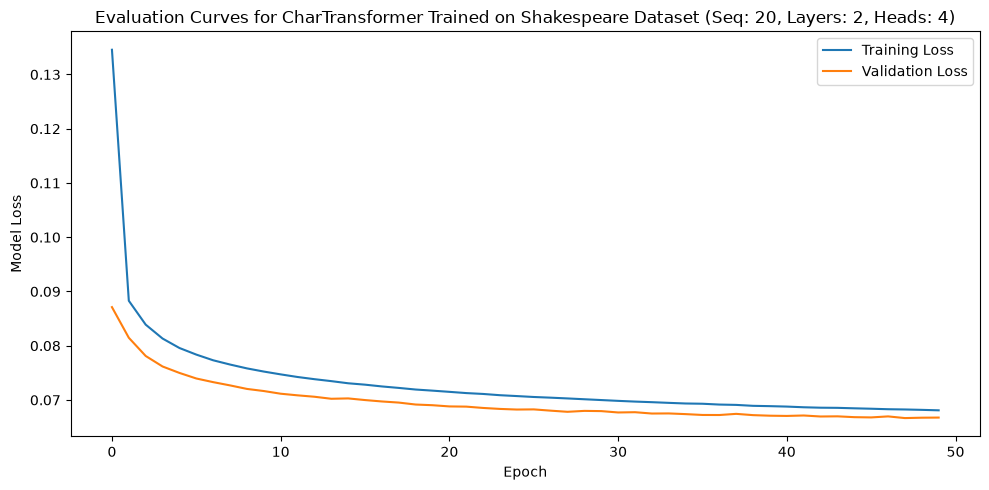



Number of Layers: 4 |   Number of heads: 2
Epoch 10:
 Loss: 0.058, Validation Loss: 0.069, Validation Accuracy: 0.9778


In [ ]:
print("=" * 70)
print("Part 1: Seq lengths 20 and 30    |   6 Transformer Configurations")
print("=" * 70)

part1()

print("=" * 60)
print("Part 2: Seq lengths 50    |   6 Transformer Configurations")
print("=" * 60)

part2()